# Datalab 5
In this datalab, we will experiment with chisquare tests, correlations tests, linear regression and logistic regression. The different methods tend to be useful for different things, so it is difficult to have one running example for all of them. However, there is a strong link between correlation tests and linear regression, so this link we will exploit here. We start with the chisquare tests. Prior to doing the datalab, please read the python page for module 5.

## Chi-square tests
There are two things we mainly use chisquare tests for: 

1. Goodness-of-fit tests
2. Independence tests

We will start with an example of the former. 

An old, grumpy professor thinks the distribution of grades in large introductory courses in the Bachelor's program at NHH should always be:

- A to the top 10\%
- B to the next 20\%
- C to the next 30\%
- D to the next 20\%
- E to the next 10\%
- F to the bottom 10\%

BED2 Financial Accounting is such a large course. Below is a barplot showing the BED2 grade distribution for fall 2023. The data is publicly available at [https://www.karakterweb.no/nhh/bed2](https://www.karakterweb.no/nhh/bed2).

![](bed2_grades.png)

## Exercise
Use the data and a chi-square test statistic to formally test whether this course follows the old, grumpy professor's distribution of grades. There is no decision to be made here, so we do not need to set a significance level. We will evaluate the p-value as a measure of how strong the evidence against the null hypothesis is. Remember to define the hypotheses! 

Relevant Python function: *scipy.stats.chisquare*.


### Solution
Let us first input the data we have been given: 

In [1]:
from scipy import stats
import numpy as np
import pandas as pd
categories = ["A","B","C","D", "E", "F"]
observed = np.array([59,114,140,85,40,33])
nulldist = np.array([0.1,0.20,0.30,0.20,0.10,0.10])

The nullhypothesis is that the grades follow the distribution of the grumpy professor. Under this hypothesis, we need to find the expected number of students that should receive each grade. This we find by simply multiplying the vector of proportions with the total number of students, i.e. the sum of the observed frequencies. 

In [2]:
expected = nulldist * observed.sum()

Let us print the data in a nicely formatted table:

In [3]:
df = pd.DataFrame({
    "Category": categories,
    "Observed": observed,
    "Expected": expected
})
print(df)

  Category  Observed  Expected
0        A        59      47.1
1        B       114      94.2
2        C       140     141.3
3        D        85      94.2
4        E        40      47.1
5        F        33      47.1


We can then conduct the test: 

In [4]:
chi2, p=stats.chisquare(f_obs = observed, f_exp=expected)
print(f"Chi-squared statistic: {chi2}")
print(f"p-value: {p}")

Chi-squared statistic: 13.370134465675864
p-value: 0.020146411730111963


The p-value is low (2%), indicating evidence against the null hypothesis. The evidence suggests that the BED2 grade distribution does not follow the suggested distribution.

## Exercise: Grade and gender
Now, let us look at the bivariate distribution of gender and grade in BED2. 

![](bed2_grades_and_gender.png)

We want to test whether gender affects the grade distribution. You may extract the data from the figure by:

In [5]:
data = {
"A": [48, 11],
"B": [83, 31],
"C": [80, 60],
"D": [33, 52],
"E": [19, 21],
"F": [13, 20]
}
# Rows: Male, Female
df = pd.DataFrame(data, index=["Male", "Female"])

Define the hypothesis and do a chi-square test. Relevant Python function: *scipy.stats.chi2_contingency*.

## Solution
The null hypothesis is that gender and grade are independent variables, while the alternative hypothesis is that they are dependent variables. Given the data as a table as above, conducting the test is easily done by:

In [6]:
# Perform the chi-squared test
chi2, p, dof, expected = stats.chi2_contingency(df)
# Print results
print("Chi-squared statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(pd.DataFrame(expected, columns=df.columns, index=df.index))

Chi-squared statistic: 42.95212106681709
p-value: 3.77856867648255e-08
Degrees of freedom: 5
Expected frequencies:
                A          B          C          D         E         F
Male    34.573248  66.802548  82.038217  49.808917  23.43949  19.33758
Female  24.426752  47.197452  57.961783  35.191083  16.56051  13.66242


The p-value is extremely low, indicating strong evidence against the null hypothesis that gender and grade are independent. Thus, the evidence suggests that grade and gender are dependent variables. 

## Correlation test
For correlation and linear regression, we will use the children's height example from the Module 5 videos. These data are included in the nhanes package for Python, so if you do not have it, you will need to run pip install nhanes (this package is not available via conda install). 

For the correlation test, suppose we want to test whether the children's height and age are correlated. Since we know that height usually increases with age, we want to test if the two variables are positively correlated. Thus, our alternative hypothesis is $H_A: r>0$ (a positive correlation coefficient between height and age). The null hypothesis is that the correlation is zero: $H_0: r=0$.

In [7]:
# Load the data
from nhanes.load import load_NHANES_data 
# I got some warnings when running this for the first time - run it twice, and it will go away
nhanes_data = load_NHANES_data()
nhanes_data.columns
children = nhanes_data.query('AgeInYearsAtScreening < 18')
children = children.rename(columns={'AgeInYearsAtScreening': 'age',
'StandingHeightCm': 'height',
'Gender' : 'gender'})
height = children[["age", "height", "gender"]].copy().dropna()
print(height.head())

C:\Users\s15052\AppData\Local\anaconda3\envs\TECH3_student\Lib\site-packages\nhanes\load.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


          age  height  gender
SEQN                         
93703.0   2.0    88.6  Female
93704.0   2.0    94.2    Male
93707.0  13.0   158.4    Male
93719.0  13.0   160.5  Female
93724.0   5.0   111.4  Female


Let us make a scatterplot of height against age, to visualize the dependence structure. 

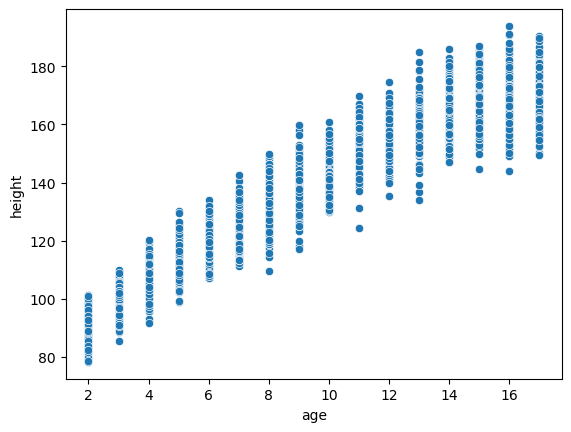

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x="age",y="height", data=height)
plt.show()

From the graph (and our intuition), height is increasing with age. We can also see from the graph that age is an integer, which may explain the large variation within an age group. Increases in age seem to be associated with increases in height, which indicates positive correlation. Let us formally test this: 

In [9]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(height["height"],  height["age"],
                         alternative='greater')

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.9495448959826561
p-value: 0.0


Clearly, the correlation is very high ($\hat r= 0.95$), and the p-value is very low. We will reject the null, and conclude that the evidendece suggests that the correlation coefficient is positive. If we wanted to check if the correlation was negative ($H_A: r<0$), we would use *alternative = 'lesser'* and for a two-sided alternative hypothesis ($H_A: r\neq 0$), we would use *alternative = 'two-sided' (which is the default argument of the function). 

## Linear regression

We have concluded that height and age are positively correlated. We now want to **model** the relationship between height and age. We may want to predict the height of children, or we may want to find out how age and gender affect the height development of a child. We will start building a model for the latter, and then select the model that performs the best for the former afterwards. We start by fitting a simple linear regression using age only. 

In [10]:
# Load packages:
from statsmodels.formula.api import ols
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
ols_model_1 = ols(formula='height ~ age',
data = height)
ols_result_1 = ols_model_1.fit()
print(ols_result_1.summary())
print("sigma2=", f"{ols_result_1.mse_resid:.1f}")

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                 2.356e+04
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:21:49   Log-Likelihood:                -9091.5
No. Observations:                2572   AIC:                         1.819e+04
Df Residuals:                    2570   BIC:                         1.820e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     85.3162      0.368    231.798      0.0

This is the standard printout table from a linear regression. There is a lot of information here.  The model we fitted here is height = $\beta_0+\beta_1$ age $+\epsilon$, where $\epsilon$ has expectation $0$ and variance $\sigma^2$. Note that the estimated variance of the residuals is not included in the OLS summary, but can be extracted using *ols.mse_resid*. We see that the estimated residual variance is $\hat\sigma^2 = 68.9$. The other parameters are estimated to $\hat\beta_0 = 85.3$ and $\hat\beta_1 = 5.5$. The interpretation of $\beta_1$ is the increase in height associated with a one-unit increase in age, or the average growth (in cm) per year. Let us plot the regression line: 

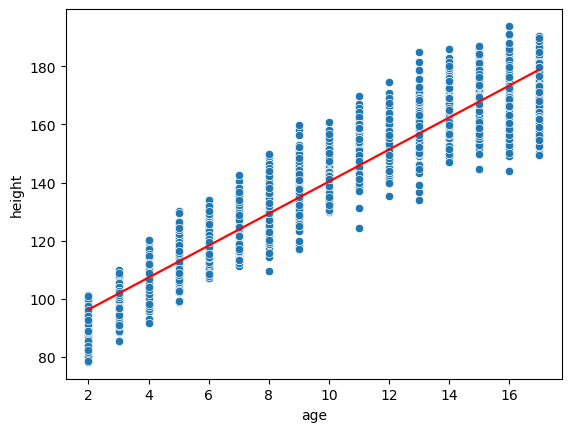

In [12]:
sns.scatterplot(x="age", y = "height", data=height)
sns.lineplot(x="age", y = ols_result_1.fittedvalues,  data = height, color = "red")
plt.show()

#### Exercise:

1. Expand the model by adding *gender*. Plot the regression lines on top of the data.
2. Set up the modelling equation and identify the estimated coefficients.
3. Is this model better than the *age-only* model above in terms of AIC?
4. Set up a model equation that allows for male and female children to have different intercepts and different slopes as functions of age.
5. Fit this model. Does it improve AIC?
6. There is some curvature in the relationship between age and height. Add an age$^2$ term as covariate. Does this improve AIC?

#### Soulutions

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                 2.356e+04
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:21:50   Log-Likelihood:                -9091.5
No. Observations:                2572   AIC:                         1.819e+04
Df Residuals:                    2570   BIC:                         1.820e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     85.3162      0.368    231.798      0.0

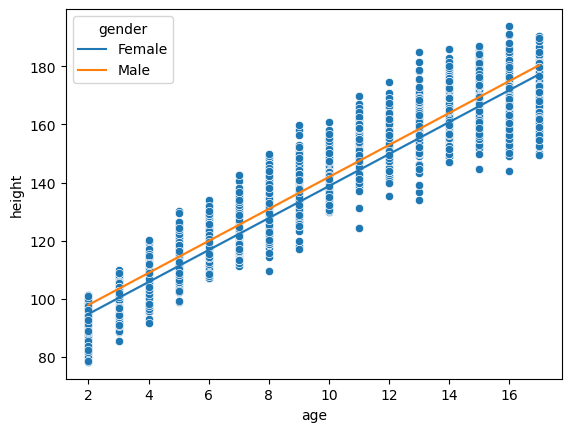

In [13]:
# 1. Expanding the model by adding gender effect
ols_model_2 = ols(formula='height ~ age + gender', data = height)
ols_result_2 = ols_model_2.fit()
print(ols_result_1.summary())
print("sigma2=", f"{ols_result_2.mse_resid:.1f}")

# Plot the regression lines: 
sns.scatterplot(x="age", y = "height", data=height)
sns.lineplot(x="age", y = ols_result_2.fittedvalues, hue = "gender", data = height)
plt.show()

2. The model is: Height = $\beta_0 +\beta_1$ age + $\beta_2$ Male $+\epsilon$, where the estimated coefficients are $\hat\beta_0 = 83.8$, $\hat\beta_1 = 5.5$ and $\hat\beta_2 = 3.13$. The residual variance is estimated to $\hat\sigma^2=66.5$. Note that gender is implemented as a dummy variable - being 0 if the child is female and 1 if the child is male. The $\beta_2$ coefficient, therefore, represents a change in the intercept from the reference gender (which here is female) for male children. The model will therefore give a regression line for each gender, where the male and female ones are parallel - same slope, but different intercepts.
3. The AIC of the gender model is $1.810\cdot10^4$. Compared to the age-only model, with AIC=$1.819\cdot10^4$, the gender model is better because the AIC is lower.
4. To have different slopes and intercepts, we need to add interaction terms. Height = $\beta_0 +\beta_1$ age + $\beta_2$ Male + $\beta_3$ Male $\times$ age $+\epsilon$. Now, the new $\beta_3$ will only contribute when Male$=1$. Thus, the regression line for Male $=0$, is $\beta_0+\beta_1$ age, while for male$=1$, we get $\beta_0+\beta_2 + (\beta_1+\beta_3)$age. The coefficient, $\beta_2$ is thus difference in intercept and $\beta_3$ is the difference in slope for male children compared to female children.

In [14]:
# 5. Fit model
ols_model_3 = ols(formula='height ~ age*gender', data=height)
ols_result_3 = ols_model_3.fit()
print(ols_result_3.summary())
print("sigma2=", f"{ols_result_3.mse_resid:.1f}")

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     8479.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:21:50   Log-Likelihood:                -9001.3
No. Observations:                2572   AIC:                         1.801e+04
Df Residuals:                    2568   BIC:                         1.803e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             86.7936      0

The parameters used in the equation in 4. can be identified as $\hat\beta_0 = 86.8$, $\hat\beta_1 = 5.17$, $\hat \beta_2 = -2.88$, and $\hat\beta_3 =0.654$, while $\hat\sigma^2 = 64.3$. All coefficients have associated p-values of zero, so everything is significantly different from zero at any reasonable significance level. There is thus a significant difference in the growth of male and female children. According to the model, females start at a higher height (the male-specific intercept coefficient is estimated to be negative), while male children have a higher growth rate ($\approx 0.65$ cm/year higher than females). 

AIC is now $1.801\cdot 10^4$, which is lower than the age+gender-intercept-model. 

In [15]:
# 6. Adding age^2: 
height["age2"] = height["age"]**2
ols_model_4 = ols(formula='height ~ age*gender + age2*gender', data=height)
ols_result_4 = ols_model_4.fit()
print(ols_result_4.summary())
print("sigma2=", f"{ols_result_4.mse_resid:.1f}")

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     7055.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:21:50   Log-Likelihood:                -8613.2
No. Observations:                2572   AIC:                         1.724e+04
Df Residuals:                    2566   BIC:                         1.727e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              68.3498    

AIC is further reduced to $1.724\cdot 10^4$, which is a huge improvement. Let us plot the regression line: 

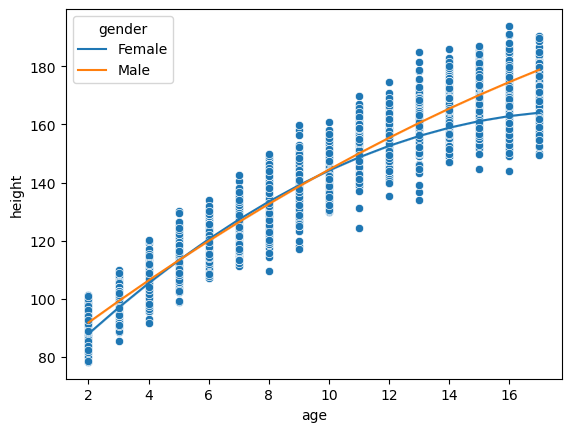

In [16]:
sns.scatterplot(x="age", y = "height", data=height)
sns.lineplot(x="age", y = ols_result_4.fittedvalues, hue = "gender", data = height)
plt.show()

As the figure illustrates, the expected height of children across gender is pretty similar when they are young, but deviates more when they enter their teens, according to the model. 

## Linear model for prediction

Now, say our main goal was not to describe gender differences in growth, but to predict a child's height based on their age and gender. We could then want to select the model that performs best in a prediction setting - that is, for unseen data. This is called out-of-sample performance. A good prediction model should have high predictive abilities on data it was not trained on. One way of doing this is to use a hold-out set (a test set), where you train the different candidate models on a portion of the data and evaluate them on another. This is the classical train-test split. 

Let's create a train-test split: 

In [17]:
# Add a age2 column: 
height["age2"] = height["age"]**2
# Random permutation of the data: 
indices = np.random.permutation(len(height))
# 80% for training, 20% for testing
split = int(0.8 * len(height))
# Extract the first ~80% indices for training and last 20% for testing: 
train_idx, test_idx = indices[:split], indices[split:]

# Construct training and test data using the indices:
train = height.iloc[train_idx] # <-- for fitting the models
test = height.iloc[test_idx]   # <-- for evaluating the models

In [18]:
# The models: 
formulas = ["height ~ age", 
            "height ~ age + gender", 
            "height ~ age*gender", 
            "height ~ age*gender+age2*gender"]
# Loop over model indices: 
for i in range(len(formulas)) :
    model = ols(formula=formulas[i], data=train) # Set up model using training data
    fit = model.fit() # Fit model 
    pred = fit.predict(test) # Predict on test data
    mse = np.sqrt(np.mean((pred - test["height"])**2)) # Calculate root mean square prediction error
    print(formulas[i], ":", f"{mse:.3f}") # Print results

height ~ age : 8.667
height ~ age + gender : 8.511
height ~ age*gender : 8.481
height ~ age*gender+age2*gender : 7.081


We can see from the output that the model with the lowest prediction error is the most complex model, which was also the best model in terms of AIC, when we use the full dataset above. This procedure only consider the point prediction, which is the most common thing to do when doing model selection. 

We will now continue with "the best model", and say we want to make a nice graph showing how the model predicts unseen children, while also taking into account the uncertainty of such a prediction. For this, we need prediction intervals!

In [19]:
# Using the most recent fit object:
pred_res = fit.get_prediction(test)
pred_df = pred_res.summary_frame(alpha=0.05)  
print(pred_df)

           mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0     92.041343  0.545121      90.972294      93.110392     78.557444   
1    113.312972  0.290123     112.744006     113.881937     99.859482   
2    148.589767  0.303066     147.995417     149.184117    135.135180   
3    155.978314  0.291089     155.407454     156.549175    142.524745   
4     97.183655  0.424623      96.350917      98.016393     83.716432   
..          ...       ...            ...            ...           ...   
510  150.059641  0.307117     149.457346     150.661935    136.604700   
511  155.488445  0.295344     154.909240     156.067651    142.034519   
512  170.553651  0.363247     169.841279     171.266023    157.093334   
513  164.199833  0.608082     163.007310     165.392355    150.705583   
514  105.521463  0.336716     104.861121     106.181804     92.063799   

     obs_ci_upper  
0      105.525242  
1      126.766461  
2      162.044354  
3      169.431884  
4      110.650879  
.. 

Using the code above, we have the mean prediction (the expected value/point prediction), the standard error of that prediction. The mean_ci_lower and mean_ci_upper constitutes the confidence interval for the expected value, while the obs_ci_lower and obs_ci_upper are 95% prediction interval. This gives the interval where new observations with 95% probability will fall into, according to the model. Lets plot it together with the test data.

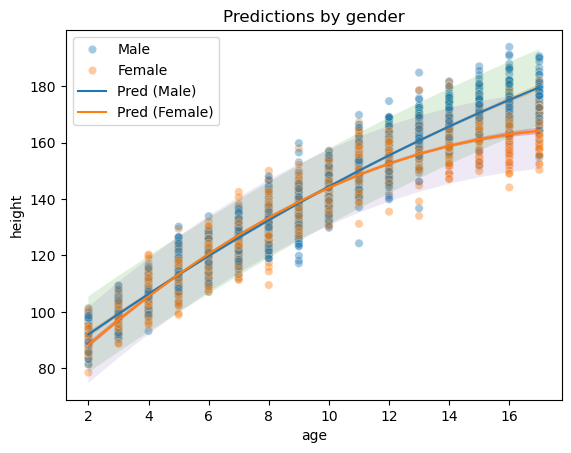

In [20]:
# Merge test data and predictions:
import pandas as pd
plot_df = pd.concat([test.reset_index(), pred_df], axis=1)
plot_df = plot_df.sort_values("age")

plt.figure()

# Scatter (train data)
sns.scatterplot(data=train, x="age", y="height", hue="gender", alpha=0.4)

# Loop over genders for clean interval plotting
for g in plot_df["gender"].unique():
    df_g = plot_df[plot_df["gender"] == g].sort_values("age")
    
    # Prediction line
    sns.lineplot(data=df_g, x="age", y="mean", label=f"Pred ({g})")
    
    # Confidence interval
    plt.fill_between(
        df_g["age"],
        df_g["mean_ci_lower"],
        df_g["mean_ci_upper"],
        alpha=0.3
    )
    
    # Prediction interval
    plt.fill_between(
        df_g["age"],
        df_g["obs_ci_lower"],
        df_g["obs_ci_upper"],
        alpha=0.15
    )

plt.xlabel("age")
plt.ylabel("height")
plt.title("Predictions by gender")
plt.legend()
plt.show()

As you can see from the figure, the prediction interval is almost as wide as the spread of the data for the various ages. Note that this is for the test data, so the model has not been trained on this observations. The prediction intervals seem well tuned to the data. Note that around 5% of the test data observations is expected to lie outside the interval. 

Another relevant interval is the confidence interval (mean_ci_lower, mean_ci_upper). While the prediction interval is an interval that will cover new observations with 95% probability, the confidence interval is about the expected value of $Y$, often referred to as $\mu$. The prediction interval will always be wider than the corresponding confidence interval. Let us compare them for the female children's heights in another plot.

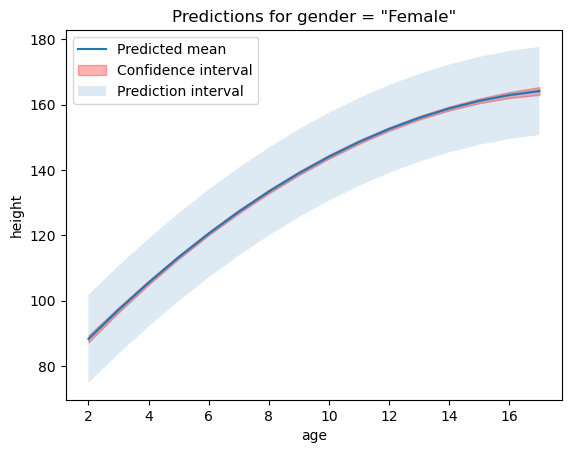

In [21]:
df_f = plot_df[plot_df["gender"] == "Female"].sort_values("age")
plt.figure()

# Predicted mean line
sns.lineplot(data=df_f, x="age", y="mean", label="Predicted mean")

# Confidence interval
plt.fill_between(
    df_f["age"],
    df_f["mean_ci_lower"],
    df_f["mean_ci_upper"],
    color = "red",
    alpha=0.3,
    label="Confidence interval"
)

# Prediction interval
plt.fill_between(
    df_f["age"],
    df_f["obs_ci_lower"],
    df_f["obs_ci_upper"],
    alpha=0.15,
    label="Prediction interval"
)

plt.xlabel("age")
plt.ylabel("height")
plt.title('Predictions for gender = "Female"')
plt.legend()
plt.show()

The dataset is quite large, so the uncertainty of the expected height at any given age is very low. 

# Cross validation
We used a simple train-test split above. An alternative to this is to use cross validation. This means that you divide the dataset into $k$ folds, and then, looping over the folds, you take out one fold at the time for testing, and use the other folds for training. The out-of-sample performence is then aggregated across the folds, making the decision of the "best model" more robust to the specific test set. 

In [22]:
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols

# The models
formulas = [
    "height ~ age",
    "height ~ age + gender",
    "height ~ age*gender",
    "height ~ age*gender + age2*gender"
]

# Initiate 10-fold CV
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Store results
results = []

# Loop over models: 
for formula in formulas:
    # Make a fresh copy for this model
    data = height.copy()
    data["Predicted"] = np.nan
    # Loop over the 10 folds:
    for train_index, test_index in kf.split(data):
        train_data = data.iloc[train_index] # Training 
        test_data = data.iloc[test_index]   # Testing

        # Fit model on training fold
        model = ols(formula=formula, data=train_data)
        trainfit = model.fit()

        # Predict on test fold
        data.iloc[test_index, data.columns.get_loc("Predicted")] = trainfit.predict(test_data)

    # Compute RMSE for this formula
    rmse = np.sqrt(np.mean((data["height"] - data["Predicted"]) ** 2))

    # Save result
    results.append({
        "formula": formula,
        "RMSE": rmse
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

print(results_df)

                             formula      RMSE
0                       height ~ age  8.303208
1              height ~ age + gender  8.157014
2                height ~ age*gender  8.023010
3  height ~ age*gender + age2*gender  6.904521


## Exercise
What does the output tell you?

### Solution
The model using a second-order polynomial in age for each gender has a much lower 10-fold cross-validated root-mean-square error (RMSE) than the other models. Clearly, it is the preferred model.